In [495]:
import pandas as pd
import numpy as np
from pathlib import Path
import re
import os
from scripts.data_preprocess import bib_to_csv
import matplotlib.pyplot as plt


#### Getting the data

In [464]:
acm_paths = ["data/raw/manual_search/ACM/acm_query_abstract_2026-03-02.bib", "data/raw/manual_search/ACM/acm_query_title_2026-03-02.bib"]
acm_raw = bib_to_csv(acm_paths, "data/processed/acm_query_2026-03-02.csv")

sd_raw = bib_to_csv("data/raw/manual_search/ScienceDirect/sd_query_2026-03-02.bib", "data/processed/sd_query_2026-03-02.csv")

In [465]:
def load_with_source(folder_path, source_name):
    folder = Path(folder_path)
    dfs = []
    for file in folder.glob("*.csv"):
        df = pd.read_csv(file)
        df["source"] = source_name
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

In [466]:
# getting the data
ieee = load_with_source("data/raw/manual_search/IEEE", "IEEE")
#springer = load_with_source("", "Springer")
sd = pd.read_csv("data/processed/sd_query_2026-03-02.csv")
sd["source"] = "ScienceDirect"

acm = pd.read_csv("data/processed/acm_query_2026-03-02.csv")
acm["source"] = "ACM"


In [467]:
# create table to keep track of counts
count_columns = ["data", "ACM", "IEEE", "ScienceDirect"]

count_db = pd.DataFrame(columns = count_columns)
count_db.loc[0] = ["raw", len(acm), len(ieee), len(sd)]
count_db

,data,ACM,IEEE,ScienceDirect
0,raw,78,337,49


In [468]:
# getting column names for all DB
acm_col = list(acm)
ieee_col = list(ieee)
#springer_col = list(springer)
sd_col = list(sd)

In [469]:
print("acm", acm_col)
print("ieee", ieee_col)
#print("springer", springer_col)
print("sd", sd_col)

acm ['Item Type', 'title', 'year', 'issue_date', 'publisher', 'address', 'volume', 'number', 'url', 'doi', 'abstract', 'journal', 'month', 'articleno', 'numpages', 'keywords', 'Authors', 'isbn', 'booktitle', 'pages', 'location', 'series', 'issn', 'source']
ieee ['Document Title', 'Authors', 'Author Affiliations', 'Publication Title', 'Date Added To Xplore', 'Publication Year', 'Volume', 'Issue', 'Start Page', 'End Page', 'Abstract', 'ISSN', 'ISBNs', 'DOI', 'Funding Information', 'PDF Link', 'Author Keywords', 'IEEE Terms', 'Mesh_Terms', 'Article Citation Count', 'Patent Citation Count', 'Reference Count', 'License', 'Online Date', 'Issue Date', 'Meeting Date', 'Publisher', 'Document Identifier', 'source']
sd ['Item Type', 'title', 'journal', 'volume', 'pages', 'year', 'issn', 'doi', 'url', 'keywords', 'abstract', 'Authors', 'note', 'number', 'source']


### prepare the individual DB so they can be merged into one later

##### we are with making sure all db only have for journal articles and conference papers / proceedings

In [470]:
# create function for filter for journal articles and conferences papers 
def filter_journal_conference(df, column_name):
    '''
    This funciton...
    '''
    # define regex pattern
    pattern = re.compile(r"conference|journal|article|proceedings", re.IGNORECASE)

    # ensure all entries are strings and strip whitespace
    cleaned_col = df[column_name].astype(str).str.strip()

    # filter for rows matching the pattern
    filtered_df = df[cleaned_col.str.contains(pattern, na = False)]

    return filtered_df

In [471]:
acm_type_filtered = filter_journal_conference(acm, "Item Type")
ieee_type_filtered = filter_journal_conference(ieee, "Document Identifier")
#springer_type_filtered = filter_journal_conference(springer, "Content Type")
sd_type_filtered = filter_journal_conference(sd, "Item Type")

In [472]:
# update counting DB
type_filter_row = pd.DataFrame([["type filtered", len(acm_type_filtered), len(ieee_type_filtered), len(sd_type_filtered)]],
                            columns = count_db.columns)

count_db = pd.concat([count_db, type_filter_row], ignore_index = True)

count_db

,data,ACM,IEEE,ScienceDirect
0,raw,78,337,49
1,type filtered,77,337,49


##### next, filter for entires containing "fall detection" AND ("privacy" OR "security") in title OR abstract

In [473]:
# create function for filter for journal articles and conferences papers 
def filter_title_abstract(df, column_names):
    '''
    This funciton...
    '''
    # define regex pattern
    pattern = re.compile(r"(?=.*fall detection)(?=.*(privacy|security))", re.IGNORECASE)

    # Initialize a boolean series of all False
    mask = pd.Series(False, index = df.index)

    # Combine columns with OR logic
    for col in column_names:
        mask |= df[col].astype(str).str.strip().str.contains(pattern, na=False)

    filtered_df = df[mask]
    return filtered_df

In [474]:

acm_titleAbstract_filtered = filter_title_abstract(acm_type_filtered, ["title", "abstract"])
ieee_titleAbstract_filtered = filter_title_abstract(ieee_type_filtered, ["Document Title", "Abstract"])
#springer_titleAbstract_filtered = filter_title_abstract(springer_type_filtered, "Content Type")
sd_titleAbstract_filtered = filter_title_abstract(sd_type_filtered, ["title", "abstract"])

/var/folders/vl/562b88_13rd3bp112l2864c00000gn/T/ipykernel_49231/1573389472.py:14: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask |= df[col].astype(str).str.strip().str.contains(pattern, na=False)
/var/folders/vl/562b88_13rd3bp112l2864c00000gn/T/ipykernel_49231/1573389472.py:14: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask |= df[col].astype(str).str.strip().str.contains(pattern, na=False)
/var/folders/vl/562b88_13rd3bp112l2864c00000gn/T/ipykernel_49231/1573389472.py:14: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask |= df[col].astype(str).str.strip().str.contains(pattern, na=False)
/var/folders/vl/562b88_13rd3bp112l2864c00000gn/T/ipykernel_49231/1573389472.py:14: UserWarning: This pattern is interpreted as a r

In [475]:
acm_titleAbstract_filtered.to_csv("data/final/acm_final_2026-03-02", index = False)
ieee_titleAbstract_filtered.to_csv("data/final/ieee_final_2026-03-02", index = False)
sd_titleAbstract_filtered.to_csv("data/final/sd_final_2026-03-02", index = False)

In [476]:
# update counting DB
titleAbstract_filter_row = pd.DataFrame([["titleAbstract filtered", len(acm_titleAbstract_filtered), len(ieee_titleAbstract_filtered), len(sd_titleAbstract_filtered)]],
                            columns = count_db.columns)

count_db = pd.concat([count_db, titleAbstract_filter_row], ignore_index = True)

count_db

,data,ACM,IEEE,ScienceDirect
0,raw,78,337,49
1,type filtered,77,337,49
2,titleAbstract filtered,35,334,37


### EDA
- timeline
- common keywords

In [477]:
# load in final data
acm_final = pd.read_csv("data/final/acm_final_2026-03-02")
ieee_final = pd.read_csv("data/final/ieee_final_2026-03-02")
sd_final = pd.read_csv("data/final/sd_final_2026-03-02")

In [478]:
acm_cols = list(acm_final.columns)
ieee_cols = list(ieee_final.columns)
sd_cols = list(sd_final.columns)

# pad shorter lists with None so all have same length
max_len = max(len(acm_cols), len(ieee_cols), len(sd_cols))
acm_cols += [None] * (max_len - len(acm_cols))
ieee_cols += [None] * (max_len - len(ieee_cols))
sd_cols += [None] * (max_len - len(sd_cols))

# create combined DataFrame
all_cols = pd.DataFrame({
    "ACM": acm_cols,
    "IEEE": ieee_cols,
    "ScienceDirect": sd_cols
})

all_cols

,ACM,IEEE,ScienceDirect
0,Item Type,Document Title,Item Type
1,title,Authors,title
2,year,Author Affiliations,journal
3,issue_date,Publication Title,volume
4,publisher,Date Added To Xplore,pages
5,address,Publication Year,year
6,volume,Volume,issn
7,number,Issue,doi
8,url,Start Page,url
9,doi,End Page,keywords


In [479]:
selected_acm_cols = ["Item Type", "year", "keywords", "source"]
selected_ieee_cols = ["Document Identifier", "Publication Year", "source", "Author Keywords", "IEEE Terms"]
selected_sd_cols = ["Item Type", "year", "keywords", "source"]


In [480]:
acm_final_filtered = acm_final[selected_acm_cols].copy()
ieee_final_filtered = ieee_final[selected_ieee_cols].copy()
sd_final_filtered = sd_final[selected_sd_cols].copy()

In [481]:
# Convert keywords columns to lists
def keywords_to_list(s):
    if pd.isna(s) or s.strip() == "":
        return []
    return [k.strip() for k in s.split(";")]

In [482]:
# ACM
#acm_final.head()
acm_final_filtered = acm_final_filtered.rename(columns={
    "Document Identifier": "Item Type",
    "year": "Year",
    "keywords": "Keywords",
    "source": "Source",
})

acm_final_filtered["Keywords"] = acm_final_filtered["Keywords"].apply(keywords_to_list)

acm_final_filtered.head()

,Item Type,Year,Keywords,Source
0,article,2025,"[Fall Detection, Wireless Sensing, mmWave Radar]",ACM
1,inproceedings,2025,"[Fall detection, Fall determination strategy, ...",ACM
2,inproceedings,2024,"[Artificial Intelligence, Embedded Computing, ...",ACM
3,inproceedings,2025,"[elderly care, fall detection, ground sensors,...",ACM
4,inproceedings,2025,"[Fall detection, Millimeter-wave radar, Neural...",ACM


In [483]:
# IEEE
#ieee_final.head()
ieee_final_filtered = ieee_final_filtered.rename(columns={
    "Document Identifier": "Item Type",
    "Publication Year": "Year",
    "Author Keywords": "Keywords",
    "source": "Source"
})

ieee_final_filtered["Keywords"] = ieee_final_filtered["Keywords"].apply(keywords_to_list)
ieee_final_filtered["IEEE Terms"] = ieee_final_filtered["IEEE Terms"].apply(keywords_to_list)

# Merge into single Keywords column
ieee_final_filtered["Keywords"] = ieee_final_filtered["Keywords"] + ieee_final_filtered["IEEE Terms"]

# Drop original keyword columns if desired
ieee_final_filtered.drop(columns=["IEEE Terms"], inplace=True)

# Resulting DataFrame
ieee_final_filtered.head()

,Item Type,Year,Source,Keywords
0,IEEE Conferences,2025,IEEE,"[Fall detection, Velodyne sensor, ACNN, DGCNN,..."
1,IEEE Conferences,2020,IEEE,"[fall, fall detection, IR array sensor, temper..."
2,IEEE Conferences,2024,IEEE,"[WiFi, CSI, ISAC, Nexmon, Fall detection syste..."
3,IEEE Conferences,2012,IEEE,"[Fall detection, video privacy, assistive moni..."
4,IEEE Journals,2026,IEEE,"[Convolutional neural network (CNN), fall dete..."


In [484]:
# ScienceDirect
sd_final_filtered = sd_final_filtered.rename(columns={
    "year": "Year",
    "keywords": "Keywords",
    "source": "Source",
})

sd_final_filtered["Keywords"] = sd_final_filtered["Keywords"].apply(keywords_to_list)

sd_final_filtered.head()

,Item Type,Year,Keywords,Source
0,article,2019,"[Optical level anonymous, Computational imagin...",ScienceDirect
1,article,2010,"[Artificial intelligence, Machine learning, NN...",ScienceDirect
2,article,2019,"[Glucose, Diabetes, ECG, Hypoglycemia, Fall de...",ScienceDirect
3,article,2025,"[Multimodal approach, fall detection, privacy-...",ScienceDirect
4,article,2023,"[Elderly population, fall detection, wireless ...",ScienceDirect


In [487]:
all_data = pd.concat(
    [acm_final_filtered, ieee_final_filtered, sd_final_filtered],
    ignore_index=True  # reset the index
)

all_data.head()

,Item Type,Year,Keywords,Source
0,article,2025,"[Fall Detection, Wireless Sensing, mmWave Radar]",ACM
1,inproceedings,2025,"[Fall detection, Fall determination strategy, ...",ACM
2,inproceedings,2024,"[Artificial Intelligence, Embedded Computing, ...",ACM
3,inproceedings,2025,"[elderly care, fall detection, ground sensors,...",ACM
4,inproceedings,2025,"[Fall detection, Millimeter-wave radar, Neural...",ACM


### stats

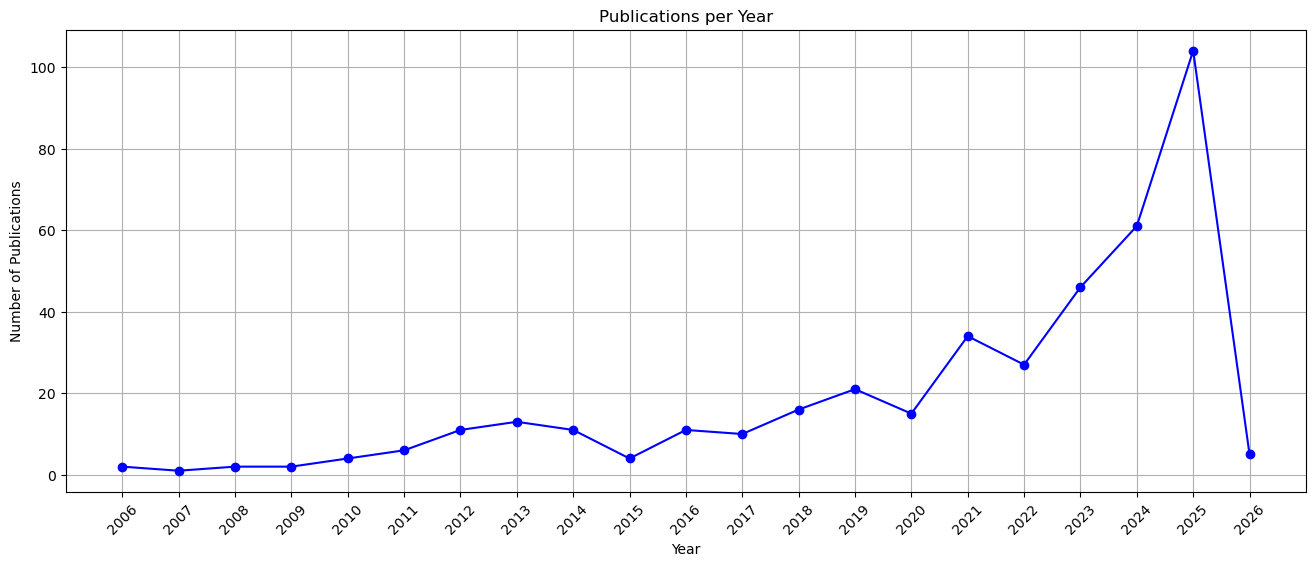

In [522]:

# Ensure 'Year' is numeric
all_data["Year"] = pd.to_numeric(all_data["Year"], errors="coerce")

# Convert to integer
all_data["Year"] = all_data["Year"].astype(int)

# Group by year and count
year_counts = all_data.groupby("Year").size()

# Plot
plt.figure(figsize=(16,6))
plt.plot(year_counts.index, year_counts.values, marker='o', linestyle='-', color='blue')
plt.xticks(year_counts.index, rotation=45)  # integer years on x-axis
plt.xlabel("Year")
plt.ylabel("Number of Publications")
plt.title("Publications per Year")
plt.grid(True)

plt.savefig("data/img/publications_per_year.png", bbox_inches = "tight")

plt.show()